CSV file not found. Generating synthetic user dataset for testing...

Dataset Preview:
  user_id  total_sessions  avg_session_duration  completion_rate  days_active
0   U1000              18             31.087241         0.848921            9
1   U1001              10             34.489465         0.556721            1
2   U1002              16             27.894044         0.105747            9
3   U1003              19             38.137571         0.358334           25
4   U1004              11             19.583476         0.655234           16


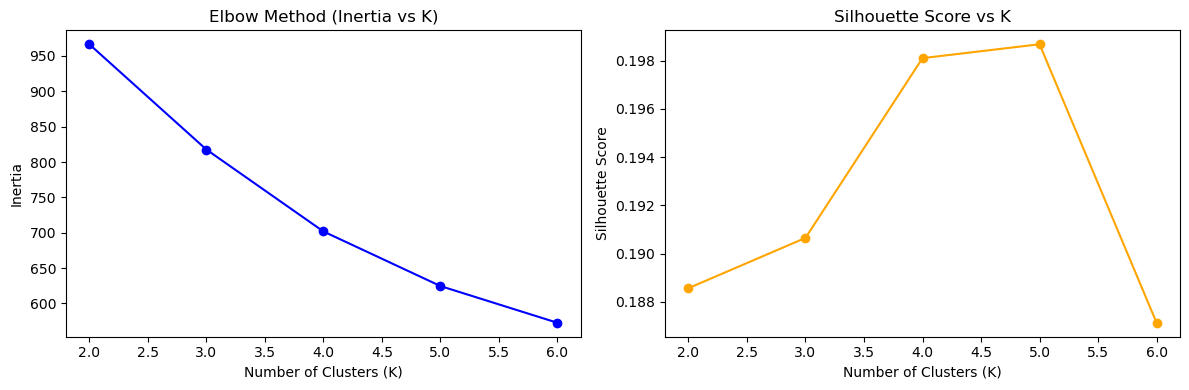


Cluster Profiling (Feature Means):
         total_sessions  avg_session_duration  completion_rate  days_active
cluster                                                                    
0             17.345679             31.826917         0.414680    16.197531
1             12.287234             22.712263         0.577103    22.297872
2             14.248000             23.685266         0.621076     6.800000

Top Recommendations for User U1000:
item_id
item_2    5.176712
item_9    2.415237
item_8    1.585393
dtype: float64

Segmentations successfully saved to 'data/processed/user_segments.csv'.


In [3]:
# ==========================================
# 05_segmentation_and_recommendations.ipynb
# ==========================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------
# Step 1: Load or Generate Data
# ------------------------------------------
file_path = 'data/processed/user_features.csv'

if os.path.exists(file_path):
    print(f"Loading data from {file_path}...")
    df_users = pd.read_csv(file_path)
else:
    print("CSV file not found. Generating synthetic user dataset for testing...")
    np.random.seed(42)
    n_users = 300
    
    df_users = pd.DataFrame({
        'user_id': [f"U{1000 + i}" for i in range(n_users)],
        'total_sessions': np.random.poisson(lam=15, size=n_users),
        'avg_session_duration': np.random.normal(loc=25, scale=7, size=n_users).clip(5, 60),
        'completion_rate': np.random.uniform(0.1, 1.0, size=n_users),
        'days_active': np.random.randint(1, 30, size=n_users)
    })

print("\nDataset Preview:")
print(df_users.head())

# ------------------------------------------
# Step 2: User Segmentation (K-Means Clustering)
# ------------------------------------------
feature_cols = ['total_sessions', 'avg_session_duration', 'completion_rate', 'days_active']
X = df_users[feature_cols].dropna()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Evaluate Optimal Clusters (K)
inertia = []
silhouette_scores = []
K_range = range(2, 7)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Evaluation Curves
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(K_range, inertia, marker='o', color='b')
ax[0].set_title('Elbow Method (Inertia vs K)')
ax[0].set_xlabel('Number of Clusters (K)')
ax[0].set_ylabel('Inertia')

ax[1].plot(K_range, silhouette_scores, marker='o', color='orange')
ax[1].set_title('Silhouette Score vs K')
ax[1].set_xlabel('Number of Clusters (K)')
ax[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

# Fit Final KMeans Model (using K=3)
optimal_k = 3
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_users['cluster'] = final_kmeans.fit_predict(X_scaled)

print("\nCluster Profiling (Feature Means):")
print(df_users.groupby('cluster')[feature_cols].mean())

# ------------------------------------------
# Step 3: Collaborative Filtering Recommendation Engine
# ------------------------------------------
# Generate synthetic user-item interaction matrix
np.random.seed(42)
items = [f"item_{i}" for i in range(1, 11)]
users = df_users['user_id'].values

interaction_data = []
for u in users:
    # Randomly select 3 to 6 items each user has interacted with
    interacted_items = np.random.choice(items, size=np.random.randint(3, 7), replace=False)
    for item in interacted_items:
        score = np.random.randint(1, 6) # Ratings between 1 and 5
        interaction_data.append({'user_id': u, 'item_id': item, 'interaction_score': score})

df_interactions = pd.DataFrame(interaction_data)

# Create User-Item Matrix
user_item_matrix = df_interactions.pivot_table(
    index='user_id', 
    columns='item_id', 
    values='interaction_score', 
    fill_value=0
)

# Compute Cosine Similarity Matrix
user_sim = cosine_similarity(user_item_matrix)
user_sim_df = pd.DataFrame(user_sim, index=user_item_matrix.index, columns=user_item_matrix.index)

# Recommendation Function
def get_user_recommendations(target_user_id, n_recommendations=3):
    if target_user_id not in user_item_matrix.index:
        return f"User ID '{target_user_id}' not found."
    
    # 5 most similar users (excluding target user)
    similar_users = user_sim_df[target_user_id].sort_values(ascending=False).iloc[1:6]
    
    # Weighted item scores based on similarity
    similar_user_profiles = user_item_matrix.loc[similar_users.index]
    weighted_scores = similar_user_profiles.T.dot(similar_users.values)
    
    # Exclude items target user has already interacted with
    target_history = user_item_matrix.loc[target_user_id]
    unseen_items = target_history[target_history == 0].index
    
    # Top recommendations
    recommendations = weighted_scores.loc[unseen_items].sort_values(ascending=False).head(n_recommendations)
    return recommendations

# Test recommendation for first user
sample_user = users[0]
print(f"\nTop Recommendations for User {sample_user}:")
print(get_user_recommendations(target_user_id=sample_user, n_recommendations=3))

# ------------------------------------------
# Step 4: Export Processed Outputs
# ------------------------------------------
os.makedirs('data/processed', exist_ok=True)
df_users[['user_id', 'cluster']].to_csv('data/processed/user_segments.csv', index=False)
print("\nSegmentations successfully saved to 'data/processed/user_segments.csv'.")